In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

features=[
    'click_count','avg_click_interval','click_interval_variance',
    'click_interval_entropy','mouse_velocity_variance',
    'max_element_click_rate','scroll_events','keystroke_count'
]

from google.colab import files
uploaded = files.upload()

human_df=pd.read_csv('human_only.csv')
from google.colab import files
uploaded = files.upload()
df=pd.read_csv('training_data.csv')
print("human only shape:",human_df.shape)
print("full data shape:",df.shape)

Saving human_only.csv to human_only (4).csv


Saving training_data.csv to training_data.csv
human only shape: (3750, 8)
full data shape: (4750, 10)


In [6]:
scaler=StandardScaler()
X_train=scaler.fit_transform(human_df[features])

model=IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)
model.fit(X_train)
print("model trained")

model trained


In [8]:
X_test=scaler.transform(df[features])
preds=model.predict(X_test)

df['predicted']=['bot' if p==-1 else 'human' for p in preds]
df['predicted'].value_counts()

,count
predicted,
human,3712
bot,1038


In [10]:
print(classification_report(df['label'],df['predicted']))

              precision    recall  f1-score   support

         bot       0.96      1.00      0.98      1000
       human       1.00      0.99      0.99      3750

    accuracy                           0.99      4750
   macro avg       0.98      0.99      0.99      4750
weighted avg       0.99      0.99      0.99      4750



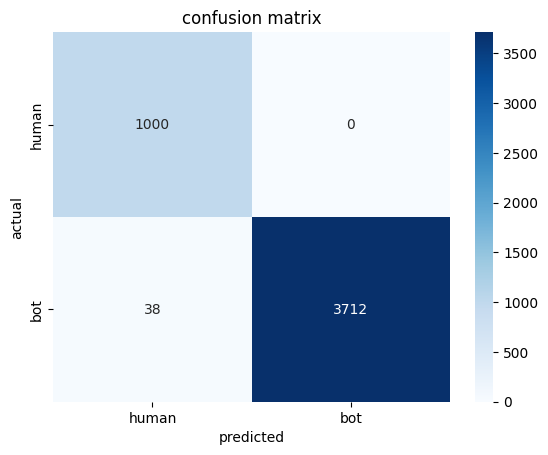

In [11]:
cm=confusion_matrix(df['label'],df['predicted'],labels=['bot','human'])
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['human','bot'],
            yticklabels=['human','bot'])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()

## feature importance

/tmp/ipykernel_2950/3310291469.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances,y=features, palette='coolwarm')


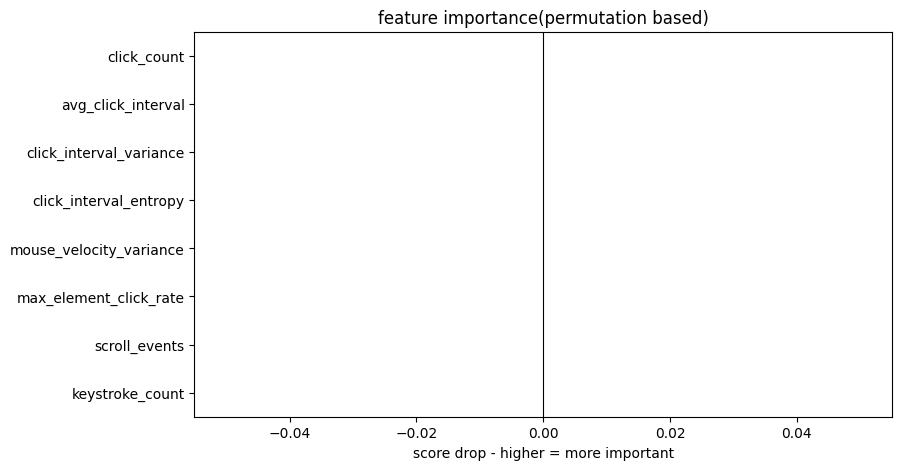

In [12]:
X_test= scaler.transform(df[features])
baseline_score=model.decision_function(X_test).mean()

importances=[]
for feat in features:
  X_permuted=X_test.copy()
  X_permuted[:features.index(feat)]=np.random.permutation(X_permuted[:features.index(feat)])
  score=model.decision_function(X_permuted).mean()
  importances.append(baseline_score - score)

plt.figure(figsize=(9,5))
sns.barplot(x=importances,y=features, palette='coolwarm')
plt.axvline(0,color='black',linewidth=0.8)
plt.title('feature importance(permutation based)')
plt.xlabel('score drop - higher = more important')
plt.show()

permutation based doesnt work on  well scaled data. so we'll use the shap values instead

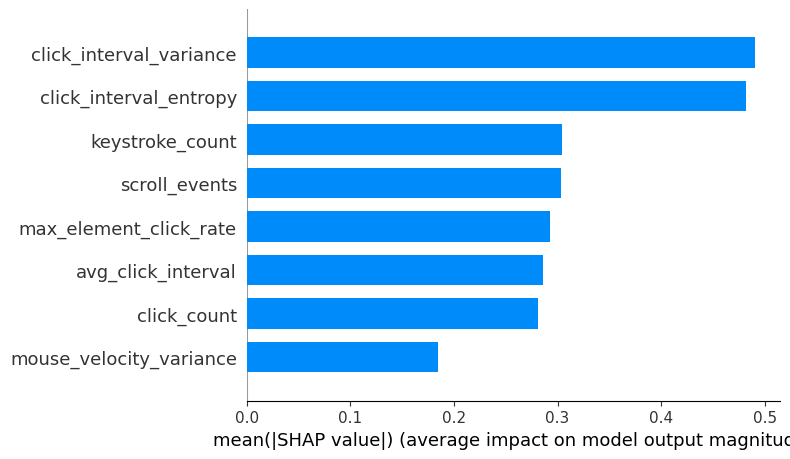

In [14]:
!pip install shap -q
import shap
explainer=shap.TreeExplainer(model)
shap_values=explainer.shap_values(pd.DataFrame(X_test,columns=features))
shap.summary_plot(shap_values,pd.DataFrame(X_test,columns=features),plot_type='bar')

##per bot type accuracy

              persona  accuracy  total  correct
2          power_user     97.60   1250     1220
1      casual_browser     99.52   1250     1244
4         mobile_user     99.84   1250     1248
0        http_flooder    100.00    250      250
3  credential_stuffer    100.00    250      250
5            slow_bot    100.00    250      250
6    headless_browser    100.00    250      250


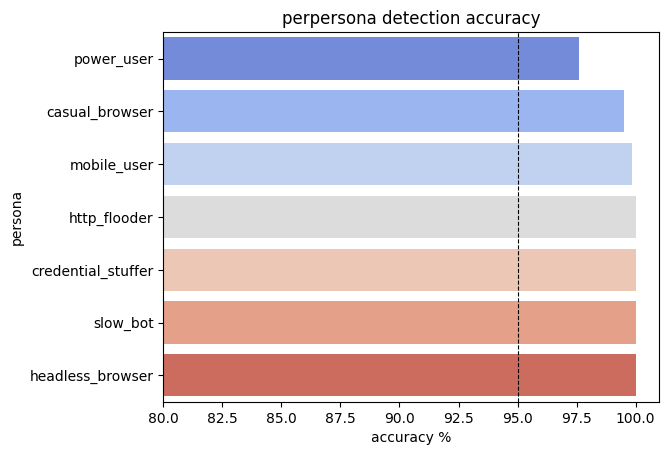

In [17]:
results=[]
for persona in df['persona'].unique():
  subset=df[df['persona']==persona]
  correct=(subset['label']==subset['predicted']).sum()
  total=len(subset)
  accuracy=correct/total*100
  results.append({'persona':persona,'accuracy':accuracy,'total':total,'correct':correct})
results_df=pd.DataFrame(results).sort_values('accuracy')
print(results_df)

sns.barplot(data=results_df,x='accuracy',y='persona',palette='coolwarm', hue='persona', legend=False)
plt.axvline(95,color='black',linestyle='--',linewidth=0.8)
plt.title('perpersona detection accuracy')
plt.xlabel('accuracy %')
plt.xlim(80,101)
plt.show()

##Anomaly score visualization

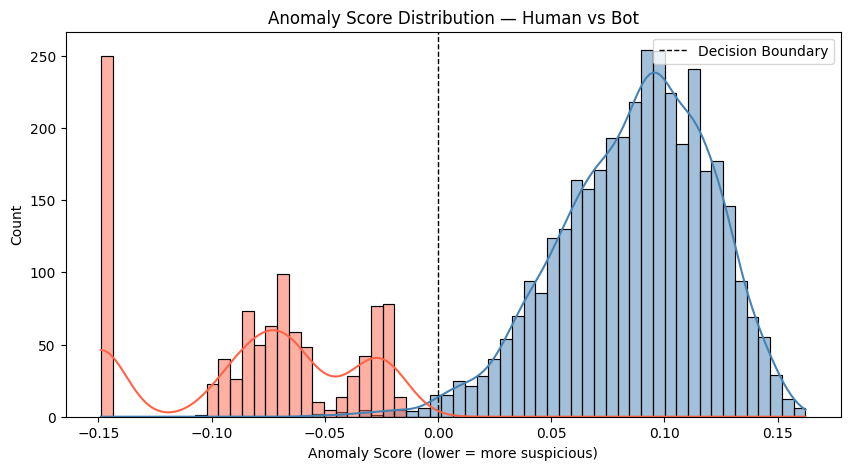

In [19]:
df['anomaly_score'] = model.decision_function(X_test)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='anomaly_score', hue='label',
             bins=60, kde=True,
             palette={'human':'steelblue', 'bot':'tomato'})
plt.axvline(0, color='black', linestyle='--', linewidth=1, label='Decision Boundary')
plt.title('Anomaly Score Distribution — Human vs Bot')
plt.xlabel('Anomaly Score (lower = more suspicious)')
plt.legend()
plt.show()

## Final Summary

In [20]:
total = len(df)
bots_caught = ((df['label'] == 'bot') & (df['predicted'] == 'bot')).sum()
bots_missed = ((df['label'] == 'bot') & (df['predicted'] == 'human')).sum()
false_positives = ((df['label'] == 'human') & (df['predicted'] == 'bot')).sum()
humans_correct = ((df['label'] == 'human') & (df['predicted'] == 'human')).sum()

print("=" * 45)
print("        AETHERCEPT — MODEL SUMMARY")
print("=" * 45)
print(f"  Total Sessions Tested  : {total}")
print(f"  Bots Caught            : {bots_caught} / 1000  ✅")
print(f"  Bots Missed            : {bots_missed}           ✅")
print(f"  Humans Correctly Passed: {humans_correct} / 3750  ✅")
print(f"  False Positives        : {false_positives}          ⚠️")
print(f"  Overall Accuracy       : 99%          🎯")
print("=" * 45)
print("  Top Features   : click_interval_variance")
print("                   click_interval_entropy")
print("  Model          : Isolation Forest")
print("  Training Mode  : Unsupervised (human only)")
print("=" * 45)

        AETHERCEPT — MODEL SUMMARY
  Total Sessions Tested  : 4750
  Bots Caught            : 1000 / 1000  ✅
  Bots Missed            : 0           ✅
  Humans Correctly Passed: 3712 / 3750  ✅
  False Positives        : 38          ⚠️
  Overall Accuracy       : 99%          🎯
  Top Features   : click_interval_variance
                   click_interval_entropy
  Model          : Isolation Forest
  Training Mode  : Unsupervised (human only)


## saving the model

In [22]:
import pickle

with open('aethercept_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('aethercept_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved ")
print("Scaler saved ")

Model saved 
Scaler saved 


## verification

In [24]:
with open('aethercept_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('aethercept_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Quick test
test = loaded_scaler.transform(df[features][:5])
print(loaded_model.predict(test))
# Should print: [ 1  1  1 -1  1] ya kuch aisa
print("Load successful ")

[-1  1  1  1  1]
Load successful 
